In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version :", tf.__version__)
print("Keras version :", keras.__version__)

SEED = 42
keras.utils.set_random_seed(SEED)  # seed python/numpy/tensorflow en un appel, pour la reproductibilité

I0000 00:00:1788285751.166946   12484 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788285751.820258   12484 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788285754.056302   12484 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version : 2.21.0
Keras version : 3.15.1


In [2]:
from pathlib import Path

In [3]:
# Configuration des chemins
import os
# Les images vivent dans nutri-ia-data-collection (voir notebooks/README.md) —
# chemin identique pour les 3 notebooks de fine-tuning, pour comparer sur le même dataset.
DATA_DIR = Path("../../nutri-ia-data-collection/data/raw/images")
assert DATA_DIR.exists(), f"Dossier introuvable : {DATA_DIR.resolve()}"

# Extensions d'images valides
EXTENSIONS_VALIDES = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# Vérification des classes disponibles
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

print(f"Nombre de classes : {len(classes)}")
print(f"Classes détectées : {classes}")

# Comptage des images par classe
print("\nNombre d'images par classe :")
total = 0
for classe in classes:
    chemin = os.path.join(DATA_DIR, classe)
    nb_images = len([
        f for f in os.listdir(chemin)
        if os.path.splitext(f)[1] in EXTENSIONS_VALIDES
    ])
    total += nb_images
    print(f"  {classe} : {nb_images} images")

print(f"\nTotal : {total} images")

Nombre de classes : 6
Classes détectées : ['alloco', 'foutou', 'kedjenou', 'mafe', 'thieboudiene', 'yassa-poulet']

Nombre d'images par classe :
  alloco : 1100 images
  foutou : 1100 images
  kedjenou : 1101 images
  mafe : 1085 images
  thieboudiene : 1100 images
  yassa-poulet : 1100 images

Total : 6586 images


In [4]:
# Chargement des données — split stratifié train/val/test (70/15/15)
# (au lieu du split 80/20 train/val de Keras : on garde un vrai jeu de test,
#  jamais vu par l'EarlyStopping/ReduceLROnPlateau, pour un score final non biaisé)
from sklearn.model_selection import train_test_split

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

class_to_idx = {name: i for i, name in enumerate(classes)}
class_names  = classes
NUM_CLASSES  = len(class_names)

filepaths, file_labels = [], []
for classe in class_names:
    classe_dir = os.path.join(DATA_DIR, classe)
    for fname in os.listdir(classe_dir):
        if os.path.splitext(fname)[1] in EXTENSIONS_VALIDES:
            filepaths.append(os.path.join(classe_dir, fname))
            file_labels.append(class_to_idx[classe])

filepaths   = np.array(filepaths)
file_labels = np.array(file_labels)

# 70 % train / 15 % val / 15 % test, split stratifié par classe
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    filepaths, file_labels, test_size=0.30, stratify=file_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

def _load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(paths, labs, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labs))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(_load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds   = make_dataset(val_paths, val_labels)
test_ds  = make_dataset(test_paths, test_labels)

print(f"Classes : {class_names}")
print(f"Images d'entraînement : {len(train_paths)}")
print(f"Images de validation  : {len(val_paths)}")
print(f"Images de test        : {len(test_paths)}")
print("\nRépartition par classe (train / val / test) :")
for classe in class_names:
    idx  = class_to_idx[classe]
    n_tr = int((train_labels == idx).sum())
    n_va = int((val_labels == idx).sum())
    n_te = int((test_labels == idx).sum())
    print(f"  {classe:15s} {n_tr:3d} / {n_va:3d} / {n_te:3d}")

Classes : ['alloco', 'foutou', 'kedjenou', 'mafe', 'thieboudiene', 'yassa-poulet']
Images d'entraînement : 4610
Images de validation  : 988
Images de test        : 988

Répartition par classe (train / val / test) :
  alloco          770 / 165 / 165
  foutou          770 / 165 / 165
  kedjenou        771 / 165 / 165
  mafe            759 / 163 / 163
  thieboudiene    770 / 165 / 165
  yassa-poulet    770 / 165 / 165


E0000 00:00:1788285825.241588   12484 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [5]:
#  Augmentation légère (appliquée uniquement au train)
from tensorflow.keras import layers, models
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [6]:
# construction du modèle ResNet
base_model = tf.keras.applications.ResNet50(
    include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False  # backbone gelé pour la phase 1
 
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
 
model = models.Model(inputs, outputs, name="ResNet50")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6)         │     12,294 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
 # PHASE 1 : entraînement de la tête (backbone gelé)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
 
# Callbacks pour optimiser l'entraînement
callbacks_phase1 = [
    # S'arrête si la validation ne s'améliore plus après 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    # Réduit le learning rate si stagnation
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]
 
print("\n=== Phase 1 : entraînement de la tête ===")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_phase1,
    verbose=1
)
print("\nEntraînement Phase 1 terminé !")


=== Phase 1 : entraînement de la tête ===
Epoch 1/20


/home/kabel/Documents/data_afrique_hub/departement_projets/projets/nutri-ia-model-training/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1788285869.221065   14758 cpu_allocator_impl.cc:82] Allocation of 102760448 exceeds 10% of free system memory.
W0000 00:00:1788285869.415024   14758 cpu_allocator_impl.cc:82] Allocation of 106463232 exceeds 10% of free system memory.
W0000 00:00:1788285869.514575   14757 cpu_allocator_impl.cc:82] Allocation of 102760448 exceeds 10% of free system memory.
W0000 00:00:1788285869.607405   14758 cpu_allocator_impl.cc:82] Allocation of 102760448 exceeds 10% of free system memory.
W0000 00:00:1788285869.781077   14758 cpu_allocator_impl.cc:82] Allocation of 102760448 exceeds

145/145 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.6679 - loss: 0.9098 - val_accuracy: 0.8381 - val_loss: 0.4702 - learning_rate: 0.0010
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.8527 - loss: 0.4419 - val_accuracy: 0.8957 - val_loss: 0.3302 - learning_rate: 0.0010
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.8872 - loss: 0.3364 - val_accuracy: 0.9059 - val_loss: 0.2788 - learning_rate: 0.0010
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9082 - loss: 0.2771 - val_accuracy: 0.9130 - val_loss: 0.2558 - learning_rate: 0.0010
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9217 - loss: 0.2362 - val_accuracy: 0.9372 - val_loss: 0.2101 - learning_rate: 0.0010
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9258 - loss: 0.2206 - val_accuracy: 0.9393 - val_loss: 0.1918 - learning_rate: 0.0010
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9302 - loss: 0.2109 - val_

In [ ]:
# Sauvegarde du modèle Phase 1 (baseline, backbone gelé) — export direct en .pt PyTorch
from keras_to_pt import export_keras_as_pt

os.makedirs("models", exist_ok=True)
test_batch = next(iter(test_ds))[0].numpy()
export_keras_as_pt(
    model,
    "models/resnet_phase1.pt",
    backbone_layer_name="resnet50",
    head_layer_names=["global_average_pooling2d", "dropout", "dense"],
    preprocess_fn=tf.keras.applications.resnet50.preprocess_input,
    test_input=test_batch,
)
print("Modèle Phase 1 sauvegardé dans models/resnet_phase1.pt ✅")
print(f"Meilleure val_accuracy (Phase 1) : {max(history_phase1.history['val_accuracy']):.2%}")

In [9]:
# PHASE 2 : fine-tuning réel — dégel des dernières couches du backbone
# (jusqu'ici on n'avait fait que de l'extraction de features : backbone
#  toujours gelé, seule la tête était entraînée)

FINE_TUNE_AT = 20  # nombre de couches finales du backbone à dégeler (ajustable)

base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR très faible pour ne pas détruire les poids ImageNet
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Phase 2 — paramètres entraînables (backbone partiellement dégelé) : {trainable_params:,}")

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

print("\n=== Phase 2 : fine-tuning du backbone ===")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_phase2,
    verbose=1,
)
print("\nFine-tuning terminé !")

Phase 2 — paramètres entraînables (backbone partiellement dégelé) : 8,943,622

=== Phase 2 : fine-tuning du backbone ===
Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.9529 - loss: 0.1379 - val_accuracy: 0.9615 - val_loss: 0.1048 - learning_rate: 1.0000e-05
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9616 - loss: 0.1121 - val_accuracy: 0.9676 - val_loss: 0.0979 - learning_rate: 1.0000e-05
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9709 - loss: 0.0826 - val_accuracy: 0.9676 - val_loss: 0.0841 - learning_rate: 1.0000e-05
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9761 - loss: 0.0735 - val_accuracy: 0.9717 - val_loss: 0.0803 - learning_rate: 1.0000e-05
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9790 - loss: 0.0653 - val_accuracy: 0.9747 - val_loss: 0.0702 - learning_rate: 1.0000e-05
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9813 - loss: 0.0592 - val_a

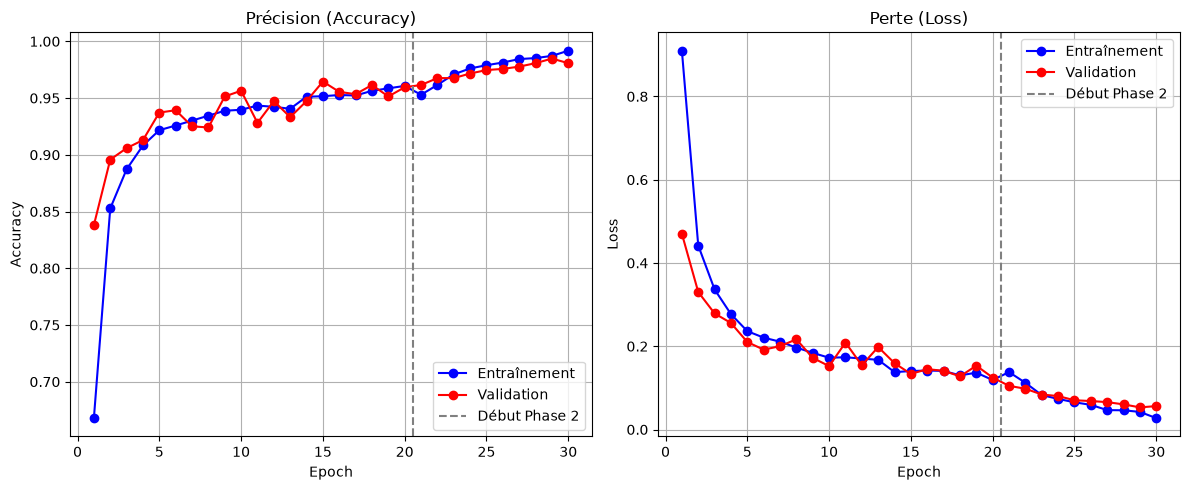

Courbes sauvegardées !


In [10]:
# Visualisation des courbes d'entraînement (Phase 1 + Phase 2 concaténées)

import matplotlib.pyplot as plt

acc      = history_phase1.history["accuracy"]     + history_finetune.history["accuracy"]
val_acc  = history_phase1.history["val_accuracy"]  + history_finetune.history["val_accuracy"]
loss     = history_phase1.history["loss"]          + history_finetune.history["loss"]
val_loss = history_phase1.history["val_loss"]      + history_finetune.history["val_loss"]
epochs = range(1, len(acc) + 1)
phase2_start = len(history_phase1.history["accuracy"]) + 0.5

plt.figure(figsize=(12, 5))

# Courbe Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc,  "b-o", label="Entraînement")
plt.plot(epochs, val_acc, "r-o", label="Validation")
plt.axvline(phase2_start, color="gray", linestyle="--", label="Début Phase 2")
plt.title("Précision (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Courbe Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss,     "b-o", label="Entraînement")
plt.plot(epochs, val_loss, "r-o", label="Validation")
plt.axvline(phase2_start, color="gray", linestyle="--", label="Début Phase 2")
plt.title("Perte (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("courbes_entrainement_resnet.png", dpi=150)
plt.tight_layout()
plt.show()
print("Courbes sauvegardées !")

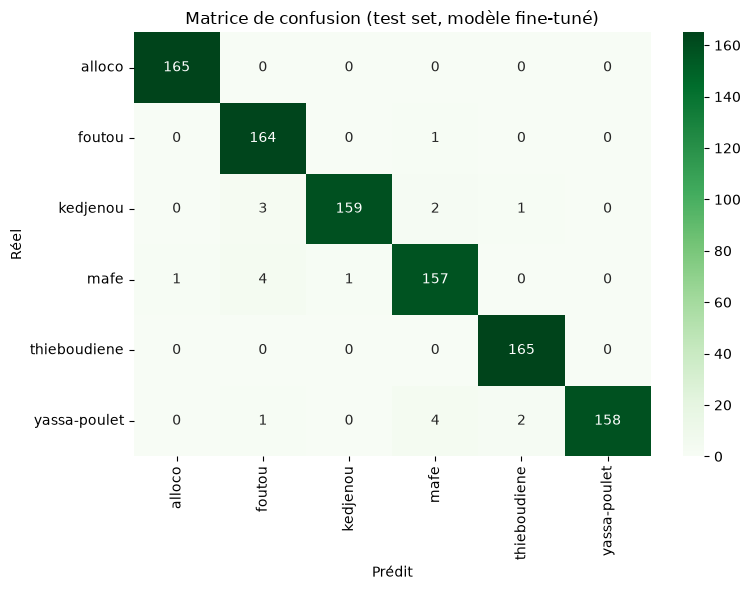


Rapport détaillé (test set) :
              precision    recall  f1-score   support

      alloco       0.99      1.00      1.00       165
      foutou       0.95      0.99      0.97       165
    kedjenou       0.99      0.96      0.98       165
        mafe       0.96      0.96      0.96       163
thieboudiene       0.98      1.00      0.99       165
yassa-poulet       1.00      0.96      0.98       165

    accuracy                           0.98       988
   macro avg       0.98      0.98      0.98       988
weighted avg       0.98      0.98      0.98       988



In [11]:
# Matrice de confusion — évaluée sur le jeu de TEST (jamais vu par les callbacks)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Prédictions sur le test set
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Greens")
plt.title("Matrice de confusion (test set, modèle fine-tuné)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("matrice_confusion_resnet.png", dpi=150)
plt.show()

print("\nRapport détaillé (test set) :")
report_text = classification_report(y_true, y_pred, target_names=class_names)
print(report_text)

In [ ]:
# Sauvegarde du modèle fine-tuné (Phase 2) + métadonnées — export direct en .pt PyTorch
import json
from pathlib import Path as _Path
from keras_to_pt import export_keras_as_pt

os.makedirs("models", exist_ok=True)
test_batch = next(iter(test_ds))[0].numpy()
export_keras_as_pt(
    model,
    "models/resnet_finetuned.pt",
    backbone_layer_name="resnet50",
    head_layer_names=["global_average_pooling2d", "dropout", "dense"],
    preprocess_fn=tf.keras.applications.resnet50.preprocess_input,
    test_input=test_batch,
)

# class_names sauvegardé à côté du modèle : sans ça, impossible de savoir plus tard
# quel index de sortie correspond à quel plat.
with open("models/resnet_classes.json", "w") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

# Rapport texte exporté (au même format que reports/*.txt utilisé pour le modèle d'embedding)
reports_dir = _Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)
with open(reports_dir / "keras_resnet_report.txt", "w") as f:
    f.write("RAPPORT — ResNet50 (entraîné avec Keras, exporté en PyTorch .pt), Phase 1 + Phase 2\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Images train/val/test : {len(train_paths)}/{len(val_paths)}/{len(test_paths)}\n")
    f.write(f"Classes : {class_names}\n\n")
    f.write(f"Meilleure val_accuracy Phase 1 : {max(history_phase1.history['val_accuracy']):.2%}\n")
    f.write(f"Meilleure val_accuracy Phase 2 : {max(history_finetune.history['val_accuracy']):.2%}\n\n")
    f.write("Rapport de classification (test set) :\n")
    f.write(report_text)

print("Modèle fine-tuné sauvegardé dans models/resnet_finetuned.pt ✅")
print("Classes sauvegardées dans models/resnet_classes.json ✅")
print("Rapport sauvegardé dans reports/keras_resnet_report.txt ✅")
print(f"Meilleure val_accuracy (Phase 2) : {max(history_finetune.history['val_accuracy']):.2%}")

In [ ]:
# Test rapide sur une image isolée — utilise le modèle Keras encore en mémoire (post-entraînement)
#
# NB : ne PAS faire torch.load(...) ici en plus de tensorflow dans le même kernel — un
# plantage natif (segfault) a été observé en mélangeant torch.load et un kernel TF déjà
# chargé. Le fichier .pt exporté est prévu pour être chargé dans un script/environnement
# PyTorch séparé (voir notebooks/README.md), pas dans ce notebook.
#
# NB2 : pas de preprocess_input ici — le modèle Keras l'applique déjà en interne
# (voir la cellule de construction du modèle) ; l'appliquer une 2e fois fausse la prédiction
# (c'est ce qui se passait dans la version précédente de cette cellule).
IMAGE_A_TESTER = "test/Mafé_au_bœuf.jpg"

img = keras.utils.load_img(IMAGE_A_TESTER, target_size=IMG_SIZE)
arr = np.expand_dims(keras.utils.img_to_array(img), axis=0)

preds = model.predict(arr, verbose=0)[0]
idx = np.argmax(preds)
print(f"Plat détecté : {class_names[idx]}  (confiance {preds[idx]:.1%})")